# SI Demo — Sentiment Analysis with DistilBERT on SST-2

**Dataset:** Stanford Sentiment Treebank v2 (SST-2) via GLUE — binary classification (Negative / Positive)  
**Model:** `distilbert-base-uncased`  
**Goal:** Fine-tune a pre-trained transformer for sequence classification as a live demo.

> **Differentiation note:** This demo uses **binary** SST-2 (2 classes).  
> The learner assignment uses a **3-class** dataset.  
> Learners must adjust `num_labels` and the `f1_score` averaging strategy — preventing copy-paste.




---
## Segment 0 — Environment Setup

Run this cell first. If any import fails, uncomment the `pip install` line and re-run.

In [1]:
# Uncomment if packages are not installed in your environment
# !pip install transformers datasets scikit-learn seaborn matplotlib torch accelerate -q

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

MODEL_CHECKPOINT = 'distilbert-base-uncased'
print('All imports successful!')
print(f'PyTorch version: {torch.__version__}')

Matplotlib is building the font cache; this may take a moment.
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/home/brandon/.local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful!
PyTorch version: 2.11.0+cu130


---
## Section 1 — Data Loading and Inspection (10 min)

`load_dataset('glue', 'sst2')` downloads SST-2 from the HuggingFace Hub and caches it locally.  
After the first run, subsequent calls load from disk instantly.

In [2]:
# CAP: reduce training split for demo speed; set to None to use full ~67K examples
CAP = 2000

dataset = load_dataset('glue', 'sst2')
print(dataset)

Generating test split: 100%|██████████| 1821/1821 [00:00<00:00, 203691.70 examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})


In [3]:
# Peek at the first three training examples
print('--- First 3 Training Examples ---')
for i in range(3):
    ex = dataset['train'][i]
    label_word = 'Positive' if ex['label'] == 1 else 'Negative'
    print(f"  [{label_word}] {ex['sentence']}")
    print(f"  Raw label integer: {ex['label']}  |  idx: {ex['idx']}")
    print()

--- First 3 Training Examples ---
  [Negative] hide new secretions from the parental units 
  Raw label integer: 0  |  idx: 0

  [Negative] contains no wit , only labored gags 
  Raw label integer: 0  |  idx: 1

  [Positive] that loves its characters and communicates something rather beautiful about human nature 
  Raw label integer: 1  |  idx: 2



Label distribution (full train split):
  0 (Negative): 29,780  (44.2%)
  1 (Positive): 37,569  (55.8%)


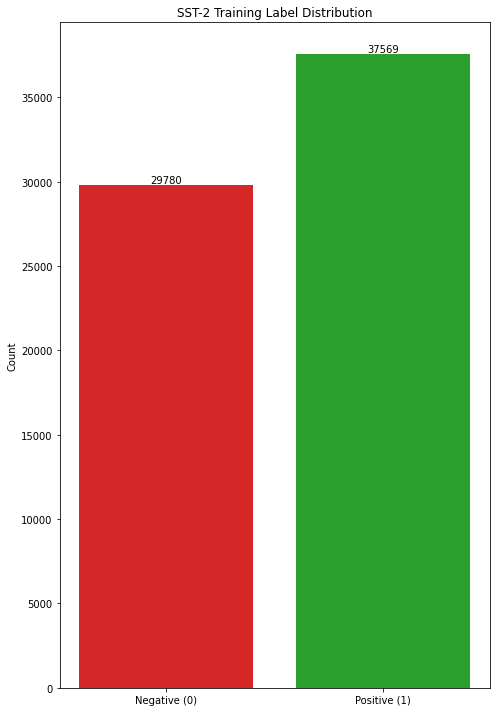

In [4]:
# Label distribution — are the classes balanced?
train_labels = dataset['train']['label']
label_counts = Counter(train_labels)

print('Label distribution (full train split):')
for label_id in sorted(label_counts):
    label_word = 'Positive' if label_id == 1 else 'Negative'
    count = label_counts[label_id]
    pct = count / len(train_labels) * 100
    print(f'  {label_id} ({label_word:8s}): {count:6,}  ({pct:.1f}%)')

# Visualize distribution
fig, ax = plt.subplots(figsize=(7, 10))
bars = ax.bar(
    ['Negative (0)', 'Positive (1)'],
    [label_counts[0], label_counts[1]],
    color=['#d62728', '#2ca02c'],
)
ax.bar_label(bars, fmt='%d')
ax.set_title('SST-2 Training Label Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [5]:
# Cap the training split if CAP is set
if CAP:
    dataset['train'] = dataset['train'].select(range(CAP))
    print(f'Training split capped at {CAP} examples for demo speed.')

print('\nFinal split sizes:')
for split in dataset:
    print(f'  {split:12s}: {len(dataset[split]):,} examples')

Training split capped at 2000 examples for demo speed.

Final split sizes:
  train       : 2,000 examples
  validation  : 872 examples
  test        : 1,821 examples


---
## Section 2 — Tokenization with `map` (10 min)

Transformers do not read text — they read **integers**. Tokenization is the translation step:  
raw string → sequence of token IDs.

**Why `from_pretrained`?**  
We must use the *same* vocabulary that was used during DistilBERT's original training.  
A different vocabulary would make the pretrained weights meaningless.

**Why `batched=True`?**  
`dataset.map` with `batched=True` sends chunks of ~1000 examples at once to the tokenizer,  
which is 10–100× faster than tokenizing one example at a time.

In [6]:
# Load the tokenizer matching our model checkpoint
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

# Demo: tokenize a single sentence and inspect the output
sample_sentence = dataset['train'][0]['sentence']
print('Original sentence:')
print(' ', sample_sentence)
print()

encoded = tokenizer(sample_sentence)
print('Token IDs:      ', encoded['input_ids'])
print('Attention mask: ', encoded['attention_mask'])
print()
print('Decoded back:   ', tokenizer.decode(encoded['input_ids']))
print(f'Token count: {len(encoded["input_ids"])}')
print()
print('Note: [CLS] at the start and [SEP] at the end are added automatically.')

Original sentence:
  hide new secretions from the parental units 

Token IDs:       [101, 5342, 2047, 3595, 8496, 2013, 1996, 18643, 3197, 102]
Attention mask:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Decoded back:    [CLS] hide new secretions from the parental units [SEP]
Token count: 10

Note: [CLS] at the start and [SEP] at the end are added automatically.


In [7]:
# Define the batch tokenization function
def tokenize_fn(examples):
    return tokenizer(
        examples['sentence'],   # The text column in SST-2
        truncation=True,        # Cut sequences longer than max_length
        padding='max_length',   # Pad shorter sequences to max_length
        max_length=128,         # All sequences → length 128
    )

# Show columns BEFORE
print('Columns BEFORE tokenization:')
print(' ', dataset['train'].column_names)

# Apply to all splits at once
tokenized_dataset = dataset.map(tokenize_fn, batched=True)

# Show columns AFTER
print('\nColumns AFTER tokenization:')
print(' ', tokenized_dataset['train'].column_names)

Columns BEFORE tokenization:
  ['sentence', 'label', 'idx']


Map: 100%|██████████| 1821/1821 [00:00<00:00, 8784.18 examples/s]


Columns AFTER tokenization:
  ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask']


In [8]:
# Prepare for the Trainer
#   1. Rename 'label' → 'labels'  (Trainer expects 'labels', plural)
#   2. Drop columns the model does not need
#   3. Set format to return PyTorch tensors

tokenized_dataset = tokenized_dataset.rename_column('label', 'labels')
tokenized_dataset = tokenized_dataset.remove_columns(['sentence', 'idx'])
tokenized_dataset.set_format('torch')

print('Final columns ready for Trainer:')
print(' ', tokenized_dataset['train'].column_names)

# Inspect one prepared example
sample = tokenized_dataset['train'][0]
print(f'\ninput_ids shape:      {sample["input_ids"].shape}')
print(f'attention_mask shape: {sample["attention_mask"].shape}')
print(f'labels:               {sample["labels"]}')

Final columns ready for Trainer:
  ['labels', 'input_ids', 'token_type_ids', 'attention_mask']

input_ids shape:      torch.Size([128])
attention_mask shape: torch.Size([128])
labels:               0


---
## Section 3 — Model Construction (5 min)

`AutoModelForSequenceClassification` loads the DistilBERT body (pretrained) and attaches a  
**new, randomly initialized classification head** (two linear layers for binary classification).

**Expected warning you will see:**
```
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint...
```
This is **correct behavior**, not an error. The body weights loaded fine; only the new head is random.  
We will train the head during fine-tuning.

**Key discussion point:** `num_labels=2` controls the output layer size.  
The learner lab has 3 classes → they must change this to `num_labels=3`.

In [9]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=2,           # Binary: 0=Negative, 1=Positive
                            # ← LEARNER LAB: change this to 3
)

print('\nClassification head:')
print(model.classifier)
print()

total_params    = model.num_parameters()
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 283.59it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Classification head:
Linear(in_features=768, out_features=2, bias=True)

Total parameters:     66,955,010
Trainable parameters: 66,955,010


---
## Section 4 — TrainingArguments Walkthrough (10 min)

`TrainingArguments` is a dataclass that controls every aspect of the training loop.  
Nothing actually trains yet — this is the configuration plan.

Walk through each parameter with the group and ask: *"What would happen if we changed X?"*

In [10]:
training_args = TrainingArguments(
    output_dir='./sst2_results',        # Where checkpoints are saved
    num_train_epochs=3,                  # Full passes over the training data
    per_device_train_batch_size=16,      # Examples per gradient update
    per_device_eval_batch_size=64,       # Larger OK — evaluation needs no gradient memory
    warmup_steps=100,                    # Linear LR ramp-up to protect pretrained weights
    weight_decay=0.01,                   # L2 regularization strength
    learning_rate=2e-5,                  # Fine-tuning LR (standard range: 1e-5 to 5e-5)
    logging_dir='./sst2_logs',           # TensorBoard log directory
    logging_steps=50,                    # Print a log row every N gradient steps
    eval_strategy='epoch',               # Evaluate at the end of each epoch
    save_strategy='epoch',               # Must match eval_strategy when using load_best
    load_best_model_at_end=True,         # Reload best checkpoint after all epochs finish
    metric_for_best_model='f1',          # 'best' is defined by validation F1
    report_to='none',                    # Suppress W&B / MLflow prompts
)

print('TrainingArguments ready.')
print(f'  epochs:         {training_args.num_train_epochs}')
print(f'  train batch:    {training_args.per_device_train_batch_size}')
print(f'  learning rate:  {training_args.learning_rate}')
print(f'  eval strategy:  {training_args.eval_strategy}')
print(f'  best metric:    {training_args.metric_for_best_model}')

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


TrainingArguments ready.
  epochs:         3
  train batch:    16
  learning rate:  2e-05
  eval strategy:  IntervalStrategy.EPOCH
  best metric:    f1


---
## Section 5 — `compute_metrics` for Binary Classification (5 min)

The `Trainer` calls this function after every evaluation run.  
It receives **raw logits** (not probabilities) and **ground-truth integer labels**.

**Key concept — `np.argmax`:**  
The model outputs one score per class. `argmax` picks the index of the highest score — that index is the predicted class.

**`average='binary'` vs `'weighted'`:**
- `'binary'` — only valid for 2-class problems; treats class 1 as the positive class.
- `'weighted'` — required for 3+ classes; weights each class's F1 by its frequency. ← **learner lab**

In [11]:
# Visual intuition: what does argmax do?
sample_logits = np.array([
    [ 2.3, -1.1],   # Very confident → class 0 (Negative)
    [-0.5,  3.2],   # Very confident → class 1 (Positive)
    [ 0.1,  0.2],   # Barely leaning → class 1 (Positive)
])
print('Logits (raw scores, one column per class):')
print(sample_logits)
print()
print('np.argmax(logits, axis=-1):', np.argmax(sample_logits, axis=-1))
print('Expected:                   [0 1 1]')

Logits (raw scores, one column per class):
[[ 2.3 -1.1]
 [-0.5  3.2]
 [ 0.1  0.2]]

np.argmax(logits, axis=-1): [0 1 1]
Expected:                   [0 1 1]


In [12]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)      # Raw scores → predicted class index
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='binary')
    # ← LEARNER LAB: change average='binary' to average='weighted'
    return {'accuracy': accuracy, 'f1': f1}

# Quick sanity check with dummy data
from transformers.trainer_utils import EvalPrediction
dummy_logits = np.array([[2.0, -1.0], [-1.0, 3.0], [1.5, 0.5], [-0.5, 2.0]])
dummy_labels = np.array([0, 1, 0, 1])
result = compute_metrics(EvalPrediction(predictions=dummy_logits, label_ids=dummy_labels))
print('Sanity check result:', result)
print('(All 4 predictions correct → accuracy=1.0, f1=1.0)')

Sanity check result: {'accuracy': 1.0, 'f1': 1.0}
(All 4 predictions correct → accuracy=1.0, f1=1.0)


---
## Section 6 — Live Smoke Test: `trainer.train()` (10 min)

We run a **50-example, 1-epoch** training loop. The goal is NOT a good model —  
it is to verify the pipeline works end-to-end and to **watch the loss decrease live**.

**What to watch:**  
The log table printed during training shows `loss` at each `logging_steps` checkpoint.  
Even on 50 examples you should see the number start around 0.7 and decrease.

In [13]:
# Carve out tiny subsets for the smoke test
smoke_train = tokenized_dataset['train'].select(range(50))
smoke_val   = tokenized_dataset['validation'].select(range(20))

print(f'Smoke train: {len(smoke_train)} examples')
print(f'Smoke val:   {len(smoke_val)} examples')

Smoke train: 50 examples
Smoke val:   20 examples


In [14]:
# Minimal TrainingArguments for the smoke test
smoke_args = TrainingArguments(
    output_dir='./smoke_results',
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    logging_steps=5,
    eval_strategy='epoch',
    save_strategy='no',
    report_to='none',
)

# Assemble the Trainer
trainer = Trainer(
    model=model,
    args=smoke_args,
    train_dataset=smoke_train,
    eval_dataset=smoke_val,
    compute_metrics=compute_metrics,
)

# --- FIRE ---
print('Starting smoke test training...')
trainer.train()
print('\nSmoke test complete!')

Starting smoke test training...


/home/brandon/.local/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.685328,0.676263,0.500000,0.000000



Smoke test complete!


---
## Section 7 — Inference and Confusion Matrix (15 min)

We use the trained model to predict on 100 validation examples,  
then visualize errors with a **confusion matrix**.

**Reading the confusion matrix:**
```
               Predicted
              Neg     Pos
True  Neg  [  TN  |  FP  ]
      Pos  [  FN  |  TP  ]
```
- **Diagonal** = correct predictions  
- **Off-diagonal** = mistakes  
- For 3 classes: matrix becomes 3×3. Look at rows to see where each true class gets misclassified.

In [15]:
# Run inference on 100 validation examples
test_subset = tokenized_dataset['validation'].select(range(100))
predictions_output = trainer.predict(test_subset)

preds        = np.argmax(predictions_output.predictions, axis=-1)
true_labels  = predictions_output.label_ids
label_names  = ['Negative', 'Positive']
# ← LEARNER LAB: update label_names to your 3 class names

print('--- Classification Report ---')
print(classification_report(true_labels, preds, target_names=label_names))

/home/brandon/.local/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


--- Classification Report ---
              precision    recall  f1-score   support

    Negative       0.48      1.00      0.65        48
    Positive       1.00      0.02      0.04        52

    accuracy                           0.49       100
   macro avg       0.74      0.51      0.35       100
weighted avg       0.75      0.49      0.33       100



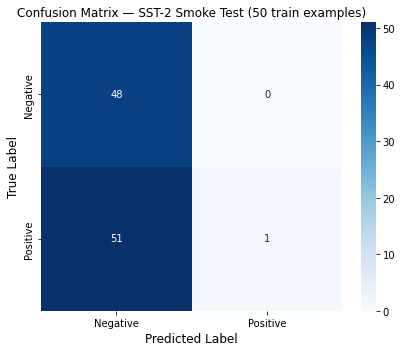

Raw confusion matrix array:
[[48  0]
 [51  1]]


In [16]:
# Confusion matrix heatmap
cm = confusion_matrix(true_labels, preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_names,
    yticklabels=label_names,
    cmap='Blues',
    ax=ax,
)
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_title('Confusion Matrix — SST-2 Smoke Test (50 train examples)', fontsize=12)
plt.tight_layout()
plt.show()

print('Raw confusion matrix array:')
print(cm)

---
## Section 8 — Push Model to Hugging Face Hub

Upload the fine-tuned model and tokenizer to your personal Hub repository so it can be reused or shared.

**Prerequisites:**
- A Hugging Face account and a write-scoped access token (Settings → Access Tokens → New Token → Write)
- `huggingface_hub` installed (already a transitive dependency of `transformers`)

Set your token in the cell below or export it as an environment variable before running:
```bash
export HF_TOKEN="hf_..."
```

In [ ]:
import os
from huggingface_hub import login

# ---------------------------------------------------------------------------
# 1. Authenticate
#    Paste your write-scoped HF token here, or set HF_TOKEN in your shell.
# ---------------------------------------------------------------------------
HF_TOKEN = os.environ.get("HF_TOKEN", "use your own HF Token")   # replace "" with your token if not set as env var
if not HF_TOKEN:
    raise ValueError("Set HF_TOKEN as an env variable or paste it directly above.")

login(token=HF_TOKEN)

# ---------------------------------------------------------------------------
# 2. Define the Hub repo (created automatically on first push if it doesn't exist)
# ---------------------------------------------------------------------------
HF_USERNAME = "BCopeland64"
REPO_NAME   = "distilbert-sst2-sentiment"
HUB_REPO_ID = f"{HF_USERNAME}/{REPO_NAME}"

# ---------------------------------------------------------------------------
# 3. Push model and tokenizer
# ---------------------------------------------------------------------------
print(f"Pushing model to: https://huggingface.co/{HUB_REPO_ID}")

model.push_to_hub(HUB_REPO_ID)
tokenizer.push_to_hub(HUB_REPO_ID)

print(f"\nDone! View your model at: https://huggingface.co/{HUB_REPO_ID}")

Pushing model to: https://huggingface.co/BCopeland64/distilbert-sst2-sentiment


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.79it/s]
Processing Files (1 / 1): 100%|██████████|  268MB /  268MB,  0.00B/s  
New Data Upload: 100%|██████████|  259MB /  259MB,  0.00B/s  



Done! View your model at: https://huggingface.co/BCopeland64/distilbert-sst2-sentiment
